# Natural Language Processing with LSTM
**Twitter Sentiment Analysis**


In [1]:
# Import Libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import pickle

from sklearn.model_selection import train_test_split 
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Embedding 
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense 
from tensorflow.keras.layers import Dropout

In [2]:
# Load the dataset 
df = pd.read_csv("training.1600000.processed.noemoticon.csv",
                  encoding="latin-1", 
                  header=None)

# Assign Column Names 
df.columns = ["sentiment", "id","date", "query", "user", "tweet"]


In [3]:
# Keep required columns
df = df[["tweet", "sentiment"]]

print("Sample Records") 
print( df.head())

Sample Records
                                               tweet  sentiment
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...          0
1  is upset that he can't update his Facebook by ...          0
2  @Kenichan I dived many times for the ball. Man...          0
3    my whole body feels itchy and like its on fire           0
4  @nationwideclass no, it's not behaving at all....          0


In [4]:
# Label Transformation
df['sentiment'] = df['sentiment'].map(
                {
                     0:0,
                     4:1
                })

# Label Distribution before Sampling
print( df["sentiment"].value_counts())

sentiment
0    800000
1    800000
Name: count, dtype: int64


In [5]:
# Sample dataset 
df = df.sample(n=50000,
               random_state=42)
print("Dataset Shape") 
print(df.shape)

Dataset Shape
(50000, 2)


In [6]:
# Data cleaning using pandas
print("Cleaning Tweets...") 

# Replace null values
df["tweet"] = df["tweet"].fillna("") 

# Convert into string
df["tweet"] = df["tweet"].astype(str) 

# Lowercase
df["tweet"] = df["tweet"].str.lower() 

#Remove @ symbol
df["tweet"] = df["tweet"].str.replace("@","",regex=False)

# Remove hashtag symbol
df["tweet"] = df["tweet"].str.replace("#","",regex=False)

# Remove extra spaces
df["tweet"] = df["tweet"].str.split().str.join(" ") 

# Remove empty rows
df = df[df["tweet"].str.len() > 3]

print("\nDataset Shape After Cleaning") 
print(df.shape)

Cleaning Tweets...

Dataset Shape After Cleaning
(50000, 2)


In [7]:
# Features and target selection
X = df['tweet']
y = df['sentiment']

In [8]:
# Tokenization
MAX_WORDS = 30000

tokenizer = Tokenizer(num_words = MAX_WORDS, oov_token = "<OOV>")

tokenizer.fit_on_texts(X)

sequences = tokenizer.texts_to_sequences(X)

In [9]:
# Padding
MAX_LEN = 40

X_pad = pad_sequences(sequences,
                      maxlen = MAX_LEN,
                      padding = "post",
                      truncating = "post")

print("Input Shape: ",X_pad.shape)

Input Shape:  (50000, 40)


In [10]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split( 
                                    X_pad,
                                    y,
                                    test_size=0.2, 
                                    random_state=42, 
                                    stratify=y)

print("Training Data Shape") 
print(X_train.shape)

print("Testing Data Shape") 
print(X_test.shape)

print("Training Label Distribution") 
print(y_train.value_counts())

print("Testing Label Distribution") 
print(y_test.value_counts())

Training Data Shape
(40000, 40)
Testing Data Shape
(10000, 40)
Training Label Distribution
sentiment
1    20011
0    19989
Name: count, dtype: int64
Testing Label Distribution
sentiment
1    5003
0    4997
Name: count, dtype: int64


In [19]:
# Build the model
model= Sequential() 

# Embedding Layer 
model.add(Embedding(input_dim=MAX_WORDS, 
                  output_dim=128, 
                  input_length=MAX_LEN))

# LSTM Layer 
model.add(LSTM(64))

# Dropout Layer 
model.add(Dropout(0.3))

# Hidden Dense Layer
model.add(Dense(32,
          activation="relu"))

# Output Layer 
model.add(Dense(1,
          activation="sigmoid"))

model.build(input_shape=(None, MAX_LEN))

print("Model Summary") 
model.summary()

Model Summary


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 40, 128)             │       3,840,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,891,521 (14.84 MB)

 Trainable params: 3,891,521 (14.84 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compile Model
model.compile(optimizer="adam", 
              loss="binary_crossentropy", 
              metrics=["accuracy"])

In [13]:
# Train the model
history= model.fit(X_train,
                   y_train,
                   epochs=5,
                   batch_size=128,
                   validation_split=0.2)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 114ms/step - accuracy: 0.5249 - loss: 0.6866 - val_accuracy: 0.6585 - val_loss: 0.6414
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 129ms/step - accuracy: 0.7349 - loss: 0.5408 - val_accuracy: 0.7446 - val_loss: 0.5219
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.8315 - loss: 0.3923 - val_accuracy: 0.7514 - val_loss: 0.5407
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 112ms/step - accuracy: 0.8785 - loss: 0.3099 - val_accuracy: 0.7346 - val_loss: 0.5803
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 117ms/step - accuracy: 0.9143 - loss: 0.2272 - val_accuracy: 0.7290 - val_loss: 0.6956


In [14]:
# Model Evaluation
loss, accuracy = model.evaluate( X_test,
                                 y_test)

print("Final Accuracy") 
print(round(accuracy * 100, 2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7418 - loss: 0.6765
Final Accuracy
74.18 %


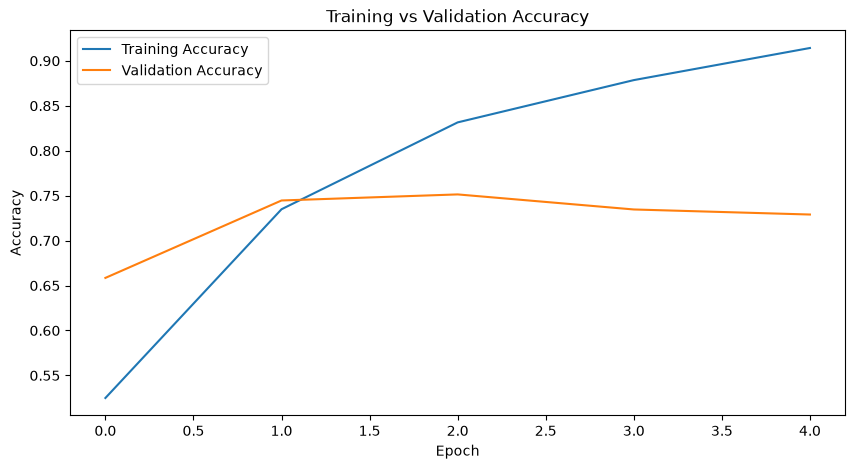

In [15]:
# Training Accuracy vs Validation Accuracy
plt.figure(figsize=(10, 5)) 

plt.plot(history.history["accuracy"],
         label="Training Accuracy")

plt.plot(history.history["val_accuracy"],
         label="Validation Accuracy")

plt.xlabel("Epoch") 
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy") 
plt.legend()
plt.show()

In [16]:
# Sentiment Analysis 
def predict_sentiment(text):

    # Convert to lowercase 
    text_processed = str(text).lower()
    #print(f"Processed Text: {text_processed}")
    
    # Convert text to sequence
    sequence= tokenizer.texts_to_sequences([text_processed])
    #print(f"Tokenized Sequence: {sequence}") 
                                            
    # Apply padding
    padded= pad_sequences(sequence, maxlen=MAX_LEN, padding="post")
    #print(f"Padded Sequence: {padded}") 
    
    # Prediction
    probability= model.predict(padded,verbose=0)[0][0]
    
    print("Positive Probability:", round(float(probability), 4))
    
    if probability >= 0.5: 
        return "Positive"
    else:
        return "Negative"

In [17]:
# Sample Predictions
print("Sample Prediction 1")
print(predict_sentiment("I absolutely love learning AI"))

print("Sample Prediction 2")
print(predict_sentiment("This is the worst experience of my life"))


Sample Prediction 1
Positive Probability: 0.9901
Positive
Sample Prediction 2
Positive Probability: 0.8983
Positive
